## Установка библиотек

In [120]:
!pip -q install pandas numpy scikit-learn matplotlib torch pyarrow

## Импорты

In [121]:
import re
import html
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from typing import List, Tuple

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

## Загрузка датасета

In [122]:
box_scores = pd.read_csv("NBA Player Box Score Stats(1950 - 2022).csv")
box_scores.head()

,Unnamed: 0,Season,Game_ID,PLAYER_NAME,Team,GAME_DATE,MATCHUP,WL,MIN,FGM,...,DREB,REB,AST,STL,BLK,TOV,PF,PTS,PLUS_MINUS,VIDEO_AVAILABLE
0,531380,1946,24600034,Adolph Hoefer,HUS,"NOV 19, 1946",HUS vs. CLR,L,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0,NaN,0
1,531378,1946,24600045,Adolph Hoefer,HUS,"NOV 23, 1946",HUS @ WAS,L,0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,NaN,0
2,531379,1946,24600042,Adolph Hoefer,HUS,"NOV 22, 1946",HUS vs. BOS,W,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,NaN,0
3,531377,1946,24600051,Adolph Hoefer,HUS,"NOV 26, 1946",HUS vs. WAS,L,0,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,NaN,0
4,531376,1946,24600061,Adolph Hoefer,HUS,"NOV 29, 1946",HUS vs. CLR,L,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,5.0,2,NaN,0


In [123]:
news_nlp = pd.read_csv("nba_news_nlp.csv")
news_nlp.head()

,news_date,team,title,url,source_name,gdelt_tone,sentiment_label_kw,sentiment_score_kw,positive_hits,negative_hits,has_injury_kw,has_win_kw,has_lose_kw,has_trade_kw,has_playoff_kw,title_len,title_word_count,nba_context_hit,source_is_sports
0,2020-01-01,MIL,NBA-best Bucks take on struggling Timberwolves,http://www.kesn1033.com/news/nba-best-bucks-ta...,kesn1033.com,1.898734,negative,-1,0,1,0,0,0,0,0,46,6,1,0
1,2020-01-01,MIN,NBA-best Bucks take on struggling Timberwolves,http://www.kesn1033.com/news/nba-best-bucks-ta...,kesn1033.com,1.898734,negative,-1,0,1,0,0,0,0,0,46,6,1,0
2,2020-01-01,GSW,"Warriors look like a new team in thrilling, un...",http://www.knbr.com/2019/12/31/warriors-look-l...,knbr.com,-1.325967,neutral,0,0,0,0,0,0,0,0,70,11,1,0
3,2020-01-01,SAS,"Warriors look like a new team in thrilling, un...",http://www.knbr.com/2019/12/31/warriors-look-l...,knbr.com,-1.325967,neutral,0,0,0,0,0,0,0,0,70,11,1,0
4,2020-01-01,GSW,Road warriors: Seahawks hoping away success co...,https://www.espn.com/blog/nfcwest/post/_/id/13...,espn.com,0.902062,neutral,0,0,0,0,0,0,0,1,67,9,1,1


In [124]:
news_daily = pd.read_csv("nba_news_daily_features.csv")
news_daily.head()

,news_date,team,news_count,avg_gdelt_tone,sum_positive_hits,sum_negative_hits,avg_sentiment_score_kw,injury_news_count,win_kw_count,lose_kw_count
0,2020-01-01,GSW,2,-0.211952,0,0,0.0,0,0,0
1,2020-01-01,LAL,1,0.223714,0,0,0.0,0,0,0
2,2020-01-01,MIL,1,1.898734,0,1,-1.0,0,0,0
3,2020-01-01,MIN,1,1.898734,0,1,-1.0,0,0,0
4,2020-01-01,PHX,1,0.223714,0,0,0.0,0,0,0


## Приведение типов дат

In [125]:
news_daily["news_date"] = pd.to_datetime(
    news_daily["news_date"], errors="coerce"
)

## Вспомогательные функции для box score датасета

In [126]:
def pick_col(columns: List[str], candidates: List[str]) -> str:
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    return None

In [127]:
def derive_opponent_from_matchup(matchup: str) -> str:
    if pd.isna(matchup):
        return np.nan
    s = str(matchup).strip()
    parts = s.split()
    if len(parts) == 0:
        return np.nan
    return parts[-1]

In [128]:
def standardize_box_scores(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    cols = df.columns.tolist()

    date_col = pick_col(cols, ["game_date", "GAME_DATE", "GAME_DATE_EST"])
    team_col = pick_col(cols, ["team", "TEAM_ABBREVIATION", "TEAM_NAME"])
    opp_col = pick_col(cols, ["opponent", "OPPONENT", "opp_team"])
    result_col = pick_col(cols, ["result", "RESULT", "WL"])
    matchup_col = pick_col(cols, ["MATCHUP"])

    if date_col is None or team_col is None:
        raise ValueError("Не удалось определить колонки даты и команды в box_scores.")

    df["game_date"] = pd.to_datetime(df[date_col], errors="coerce")
    df["team"] = df[team_col].astype(str).str.strip()

    if opp_col is not None:
        df["opponent"] = df[opp_col].astype(str).str.strip()
    elif matchup_col is not None:
        df["opponent"] = df[matchup_col].apply(derive_opponent_from_matchup)
    else:
        raise ValueError("Не удалось определить колонку соперника.")

    if result_col is not None:
        df["result"] = df[result_col].astype(str).str.strip()
    else:
        df["result"] = np.nan

    return df

In [129]:
box_scores_std = standardize_box_scores(box_scores)

print(box_scores_std.shape)
box_scores_std[["game_date", "team", "opponent", "result"]].head()

(1309778, 33)


,game_date,team,opponent,result
0,1946-11-19,HUS,CLR,L
1,1946-11-23,HUS,WAS,L
2,1946-11-22,HUS,BOS,W
3,1946-11-26,HUS,WAS,L
4,1946-11-29,HUS,CLR,L


## Проверка доступных статистических колонок

In [130]:
candidate_stat_cols = [
    "PTS", "REB", "AST", "TOV", "PF",
    "STL", "BLK",
    "FGM", "FGA", "FG3M", "FG3A", "FTM", "FTA",
    "OREB", "DREB", "MIN"
]

available_stat_cols = [c for c in candidate_stat_cols if c in box_scores_std.columns]
available_stat_cols

['PTS',
 'REB',
 'AST',
 'TOV',
 'PF',
 'STL',
 'BLK',
 'FGM',
 'FGA',
 'FG3M',
 'FG3A',
 'FTM',
 'FTA',
 'OREB',
 'DREB',
 'MIN']

## Агрегация player-level → team-game level

In [131]:
agg_dict = {col: "sum" for col in available_stat_cols}
agg_dict["result"] = "first"

team_game = (
    box_scores_std
    .dropna(subset=["game_date", "team", "opponent"])
    .groupby(["game_date", "team", "opponent"], as_index=False)
    .agg(agg_dict)
)

team_game.head()

,game_date,team,opponent,PTS,REB,AST,TOV,PF,STL,BLK,FGM,FGA,FG3M,FG3A,FTM,FTA,OREB,DREB,MIN,result
0,1946-11-01,HUS,NYK,66,0.0,0.0,0.0,25.0,0.0,0.0,25,0.0,0.0,0.0,16,29.0,0.0,0.0,0,L
1,1946-11-01,NYK,HUS,68,0.0,0.0,0.0,23.0,0.0,0.0,24,0.0,0.0,0.0,20,26.0,0.0,0.0,0,W
2,1946-11-02,BOM,PIT,56,0.0,0.0,0.0,21.0,0.0,0.0,20,59.0,0.0,0.0,16,0.0,0.0,0.0,0,W
3,1946-11-02,BOS,PRO,53,0.0,0.0,0.0,0.0,0.0,0.0,21,0.0,0.0,0.0,11,0.0,0.0,0.0,0,L
4,1946-11-02,CHS,NYK,63,0.0,0.0,0.0,20.0,0.0,0.0,21,0.0,0.0,0.0,21,0.0,0.0,0.0,0,W


## Базовые производные признаки

In [132]:
team_game = team_game.copy()

team_game["win_flag"] = (team_game["result"] == "W").astype(int)

if {"FGM", "FGA"}.issubset(team_game.columns):
    team_game["fg_pct"] = team_game["FGM"] / team_game["FGA"].replace(0, np.nan)

if {"FG3M", "FG3A"}.issubset(team_game.columns):
    team_game["fg3_pct"] = team_game["FG3M"] / team_game["FG3A"].replace(0, np.nan)

if {"FTM", "FTA"}.issubset(team_game.columns):
    team_game["ft_pct"] = team_game["FTM"] / team_game["FTA"].replace(0, np.nan)

team_game = team_game.sort_values(["team", "game_date"]).reset_index(drop=True)
team_game.head()

,game_date,team,opponent,PTS,REB,AST,TOV,PF,STL,BLK,...,FTM,FTA,OREB,DREB,MIN,result,win_flag,fg_pct,fg3_pct,ft_pct
0,1949-11-03,AND,TCB,110,0.0,0.0,0.0,0.0,0.0,0.0,...,30,36.0,0.0,0.0,0,W,1,NaN,NaN,0.833333
1,1949-11-08,AND,BOM,70,0.0,0.0,0.0,0.0,0.0,0.0,...,18,20.0,0.0,0.0,0,W,1,NaN,NaN,0.900000
2,1949-11-09,AND,TCB,102,0.0,0.0,0.0,0.0,0.0,0.0,...,28,45.0,0.0,0.0,0,W,1,NaN,NaN,0.622222
3,1949-11-12,AND,SYR,69,0.0,0.0,0.0,0.0,0.0,0.0,...,25,32.0,0.0,0.0,0,L,0,NaN,NaN,0.781250
4,1949-11-13,AND,WAT,81,0.0,0.0,0.0,0.0,0.0,0.0,...,27,36.0,0.0,0.0,0,W,1,NaN,NaN,0.750000


## Формирование game_id

In [133]:
team_game["team_pair_min"] = team_game[["team", "opponent"]].min(axis=1)
team_game["team_pair_max"] = team_game[["team", "opponent"]].max(axis=1)

team_game["game_id"] = (
    team_game["game_date"].dt.strftime("%Y-%m-%d") + "_" +
    team_game["team_pair_min"] + "_" +
    team_game["team_pair_max"]
)

team_game[["game_date", "team", "opponent", "game_id"]].head()

,game_date,team,opponent,game_id
0,1949-11-03,AND,TCB,1949-11-03_AND_TCB
1,1949-11-08,AND,BOM,1949-11-08_AND_BOM
2,1949-11-09,AND,TCB,1949-11-09_AND_TCB
3,1949-11-12,AND,SYR,1949-11-12_AND_SYR
4,1949-11-13,AND,WAT,1949-11-13_AND_WAT


## Исторические rolling-признаки

In [134]:
team_game = team_game.sort_values(["team", "game_date"]).copy()

base_rolling_cols = [c for c in ["PTS", "REB", "AST", "TOV", "PF", "win_flag"] if c in team_game.columns]
extra_rolling_cols = [c for c in ["fg_pct", "fg3_pct", "ft_pct"] if c in team_game.columns]

In [135]:
for window, min_p in [(3, 2), (5, 3), (10, 5)]:
    for col in base_rolling_cols + extra_rolling_cols:
        team_game[f"{col.lower()}_last{window}"] = (
            team_game
            .groupby("team")[col]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=min_p).mean())
        )

In [136]:
team_game.head(10)

,game_date,team,opponent,PTS,REB,AST,TOV,PF,STL,BLK,...,ft_pct_last5,pts_last10,reb_last10,ast_last10,tov_last10,pf_last10,win_flag_last10,fg_pct_last10,fg3_pct_last10,ft_pct_last10
0,1949-11-03,AND,TCB,110,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1949-11-08,AND,BOM,70,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1949-11-09,AND,TCB,102,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1949-11-12,AND,SYR,69,0.0,0.0,0.0,0.0,0.0,0.0,...,0.785185,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1949-11-13,AND,WAT,81,0.0,0.0,0.0,0.0,0.0,0.0,...,0.784201,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1949-11-15,AND,INO,83,0.0,0.0,0.0,0.0,0.0,0.0,...,0.777361,86.400000,0.0,0.0,0.0,0.000000,0.800000,NaN,NaN,0.777361
6,1949-11-19,AND,MNL,83,0.0,0.0,0.0,0.0,0.0,0.0,...,0.738472,85.833333,0.0,0.0,0.0,0.000000,0.833333,NaN,NaN,0.754282
7,1949-11-21,AND,BOS,85,0.0,0.0,0.0,0.0,0.0,0.0,...,0.699936,85.428571,0.0,0.0,0.0,0.000000,0.857143,NaN,NaN,0.747573
8,1949-11-24,AND,SYR,123,0.0,0.0,0.0,66.0,0.0,0.0,...,0.717596,85.375000,0.0,0.0,0.0,0.000000,0.750000,NaN,NaN,0.742942
9,1949-11-26,AND,BOM,73,0.0,0.0,0.0,0.0,0.0,0.0,...,0.713346,89.555556,0.0,0.0,0.0,7.333333,0.666667,NaN,NaN,0.744838


## Подготовка news daily features

Очень важно избежать data leakage.
Поэтому новостные признаки для матча должны использовать только предыдущие дни, а не новости того же дня, которые могли выйти уже после игры.

In [137]:
news_daily = news_daily.copy()
news_daily["news_date"] = pd.to_datetime(news_daily["news_date"], errors="coerce")
news_daily["team"] = news_daily["team"].astype(str).str.strip()

news_daily = news_daily.sort_values(["team", "news_date"]).reset_index(drop=True)
news_daily.head()

,news_date,team,news_count,avg_gdelt_tone,sum_positive_hits,sum_negative_hits,avg_sentiment_score_kw,injury_news_count,win_kw_count,lose_kw_count
0,2020-01-04,ATL,3,-0.063511,0,0,0.0,0,0,0
1,2020-01-05,ATL,1,-2.260870,0,0,0.0,0,0,0
2,2020-01-13,ATL,1,-0.949796,1,0,1.0,0,0,0
3,2020-01-16,ATL,2,0.828125,0,0,0.0,0,0,0
4,2020-01-17,ATL,1,1.171875,0,0,0.0,0,0,0


## Формируем ежедневную панель новостей

In [138]:
all_teams = sorted(team_game["team"].dropna().unique())
all_dates = pd.date_range(team_game["game_date"].min(), team_game["game_date"].max(), freq="D")

news_panel = pd.MultiIndex.from_product(
    [all_teams, all_dates],
    names=["team", "news_date"]
).to_frame(index=False)

news_panel.head()

,team,news_date
0,AND,1946-11-01
1,AND,1946-11-02
2,AND,1946-11-03
3,AND,1946-11-04
4,AND,1946-11-05


In [139]:
news_panel = news_panel.merge(
    news_daily,
    on=["team", "news_date"],
    how="left"
)

news_panel.head()

,team,news_date,news_count,avg_gdelt_tone,sum_positive_hits,sum_negative_hits,avg_sentiment_score_kw,injury_news_count,win_kw_count,lose_kw_count
0,AND,1946-11-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AND,1946-11-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AND,1946-11-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AND,1946-11-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AND,1946-11-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Заполнение пропусков и выбор news-признаков

In [140]:
news_feature_cols = [c for c in news_panel.columns if c not in ["team", "news_date"]]
news_feature_cols

['news_count',
 'avg_gdelt_tone',
 'sum_positive_hits',
 'sum_negative_hits',
 'avg_sentiment_score_kw',
 'injury_news_count',
 'win_kw_count',
 'lose_kw_count']

In [141]:
for col in news_feature_cols:
    if pd.api.types.is_numeric_dtype(news_panel[col]):
        news_panel[col] = news_panel[col].fillna(0)

In [142]:
news_panel = news_panel.sort_values(["team", "news_date"]).reset_index(drop=True)
news_panel.head()

,team,news_date,news_count,avg_gdelt_tone,sum_positive_hits,sum_negative_hits,avg_sentiment_score_kw,injury_news_count,win_kw_count,lose_kw_count
0,AND,1946-11-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,AND,1946-11-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AND,1946-11-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AND,1946-11-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AND,1946-11-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## News lag и rolling-признаки

Используем только предыдущие дни.

In [143]:
numeric_news_cols = [
    c for c in news_feature_cols
    if pd.api.types.is_numeric_dtype(news_panel[c])
]
numeric_news_cols

['news_count',
 'avg_gdelt_tone',
 'sum_positive_hits',
 'sum_negative_hits',
 'avg_sentiment_score_kw',
 'injury_news_count',
 'win_kw_count',
 'lose_kw_count']

In [144]:
for col in numeric_news_cols:
    news_panel[f"{col}_lag1"] = news_panel.groupby("team")[col].shift(1)

for window in [3, 7]:
    for col in numeric_news_cols:
        news_panel[f"{col}_rollmean_{window}"] = (
            news_panel.groupby("team")[col]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
        )
        news_panel[f"{col}_rollsum_{window}"] = (
            news_panel.groupby("team")[col]
            .transform(lambda s: s.shift(1).rolling(window, min_periods=1).sum())
        )

In [145]:
news_panel.head()

,team,news_date,news_count,avg_gdelt_tone,sum_positive_hits,sum_negative_hits,avg_sentiment_score_kw,injury_news_count,win_kw_count,lose_kw_count,...,sum_negative_hits_rollmean_7,sum_negative_hits_rollsum_7,avg_sentiment_score_kw_rollmean_7,avg_sentiment_score_kw_rollsum_7,injury_news_count_rollmean_7,injury_news_count_rollsum_7,win_kw_count_rollmean_7,win_kw_count_rollsum_7,lose_kw_count_rollmean_7,lose_kw_count_rollsum_7
0,AND,1946-11-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AND,1946-11-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,AND,1946-11-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,AND,1946-11-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,AND,1946-11-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Merge новостей с матчами

In [146]:
team_game_with_news = team_game.merge(
    news_panel,
    left_on=["team", "game_date"],
    right_on=["team", "news_date"],
    how="left"
)

team_game_with_news.head()

,game_date,team,opponent,PTS,REB,AST,TOV,PF,STL,BLK,...,sum_negative_hits_rollmean_7,sum_negative_hits_rollsum_7,avg_sentiment_score_kw_rollmean_7,avg_sentiment_score_kw_rollsum_7,injury_news_count_rollmean_7,injury_news_count_rollsum_7,win_kw_count_rollmean_7,win_kw_count_rollsum_7,lose_kw_count_rollmean_7,lose_kw_count_rollsum_7
0,1949-11-03,AND,TCB,110,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1949-11-08,AND,BOM,70,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1949-11-09,AND,TCB,102,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1949-11-12,AND,SYR,69,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1949-11-13,AND,WAT,81,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [147]:
if "news_date" in team_game_with_news.columns:
    team_game_with_news = team_game_with_news.drop(columns=["news_date"])

for col in team_game_with_news.columns:
    if col not in ["game_date", "team", "opponent", "result", "game_id"] and pd.api.types.is_numeric_dtype(team_game_with_news[col]):
        team_game_with_news[col] = team_game_with_news[col].fillna(0)

team_game_with_news.head()

,game_date,team,opponent,PTS,REB,AST,TOV,PF,STL,BLK,...,sum_negative_hits_rollmean_7,sum_negative_hits_rollsum_7,avg_sentiment_score_kw_rollmean_7,avg_sentiment_score_kw_rollsum_7,injury_news_count_rollmean_7,injury_news_count_rollsum_7,win_kw_count_rollmean_7,win_kw_count_rollsum_7,lose_kw_count_rollmean_7,lose_kw_count_rollsum_7
0,1949-11-03,AND,TCB,110,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1949-11-08,AND,BOM,70,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1949-11-09,AND,TCB,102,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1949-11-12,AND,SYR,69,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1949-11-13,AND,WAT,81,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [148]:
team_game_with_news = team_game_with_news[
    team_game_with_news["game_date"].dt.year >= 2020
].copy()

## Формирование match-level dataset

Теперь строим датасет вида:

* признаки команды

* признаки соперника

* целевая переменная

In [149]:
left = team_game_with_news.copy()
right = team_game_with_news.copy()

match_df = left.merge(
    right,
    on="game_id",
    how="inner",
    suffixes=("_team", "_opp")
)

match_df = match_df[match_df["team_team"] != match_df["team_opp"]].copy()
match_df = match_df.drop_duplicates(subset=["game_id", "team_team"]).reset_index(drop=True)

match_df.head()

,game_date_team,team_team,opponent_team,PTS_team,REB_team,AST_team,TOV_team,PF_team,STL_team,BLK_team,...,sum_negative_hits_rollmean_7_opp,sum_negative_hits_rollsum_7_opp,avg_sentiment_score_kw_rollmean_7_opp,avg_sentiment_score_kw_rollsum_7_opp,injury_news_count_rollmean_7_opp,injury_news_count_rollsum_7_opp,win_kw_count_rollmean_7_opp,win_kw_count_rollsum_7_opp,lose_kw_count_rollmean_7_opp,lose_kw_count_rollsum_7_opp
0,2020-01-03,ATL,BOS,106,42.0,26.0,14.0,24.0,6.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-01-04,ATL,IND,116,40.0,22.0,13.0,28.0,8.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-06,ATL,DEN,115,34.0,24.0,10.0,22.0,3.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-08,ATL,HOU,115,54.0,20.0,11.0,29.0,6.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-10,ATL,WAS,101,56.0,19.0,18.0,26.0,5.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Отбор признаков команды и соперника

In [150]:
team_feature_cols = []

for col in match_df.columns:
    if col.endswith("_team"):
        base = col[:-5]
        if base not in ["game_date", "team", "opponent", "result", "game_id", "team_pair_min", "team_pair_max"]:
            if pd.api.types.is_numeric_dtype(match_df[col]):
                team_feature_cols.append(base)

len(team_feature_cols), team_feature_cols[:30]

(95,
 ['PTS',
  'REB',
  'AST',
  'TOV',
  'PF',
  'STL',
  'BLK',
  'FGM',
  'FGA',
  'FG3M',
  'FG3A',
  'FTM',
  'FTA',
  'OREB',
  'DREB',
  'MIN',
  'win_flag',
  'fg_pct',
  'fg3_pct',
  'ft_pct',
  'pts_last3',
  'reb_last3',
  'ast_last3',
  'tov_last3',
  'pf_last3',
  'win_flag_last3',
  'fg_pct_last3',
  'fg3_pct_last3',
  'ft_pct_last3',
  'pts_last5'])

## Разностные признаки team - opponent

In [151]:
for base in team_feature_cols:
    team_col = f"{base}_team"
    opp_col = f"{base}_opp"
    if team_col in match_df.columns and opp_col in match_df.columns:
        match_df[f"{base}_diff"] = match_df[team_col] - match_df[opp_col]

In [152]:
match_df.head()

,game_date_team,team_team,opponent_team,PTS_team,REB_team,AST_team,TOV_team,PF_team,STL_team,BLK_team,...,sum_negative_hits_rollmean_7_diff,sum_negative_hits_rollsum_7_diff,avg_sentiment_score_kw_rollmean_7_diff,avg_sentiment_score_kw_rollsum_7_diff,injury_news_count_rollmean_7_diff,injury_news_count_rollsum_7_diff,win_kw_count_rollmean_7_diff,win_kw_count_rollsum_7_diff,lose_kw_count_rollmean_7_diff,lose_kw_count_rollsum_7_diff
0,2020-01-03,ATL,BOS,106,42.0,26.0,14.0,24.0,6.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2020-01-04,ATL,IND,116,40.0,22.0,13.0,28.0,8.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2020-01-06,ATL,DEN,115,34.0,24.0,10.0,22.0,3.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2020-01-08,ATL,HOU,115,54.0,20.0,11.0,29.0,6.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2020-01-10,ATL,WAS,101,56.0,19.0,18.0,26.0,5.0,9.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Целевая переменная

In [153]:
match_df["target_win"] = match_df["win_flag_team"].astype(int)

match_df[["team_team", "opponent_team", "game_date_team", "target_win"]].head()

,team_team,opponent_team,game_date_team,target_win
0,ATL,BOS,2020-01-03,0
1,ATL,IND,2020-01-04,1
2,ATL,DEN,2020-01-06,0
3,ATL,HOU,2020-01-08,0
4,ATL,WAS,2020-01-10,0


## Формируем итоговый список признаков

Будем использовать:

* rolling признаки команды

* rolling news признаки команды

* разности команда − соперник

In [154]:
allowed_team_patterns = [
    "_last3_team",
    "_last5_team",
    "_last10_team",
    "_lag1_team",
    "_rollmean_3_team",
    "_rollmean_7_team",
    "_rollsum_3_team",
    "_rollsum_7_team",
]

safe_team_feature_cols = [
    c for c in match_df.columns
    if pd.api.types.is_numeric_dtype(match_df[c])
    and any(pattern in c for pattern in allowed_team_patterns)
]

print("Количество безопасных team-признаков:", len(safe_team_feature_cols))
safe_team_feature_cols[:30]

Количество безопасных team-признаков: 67


['pts_last3_team',
 'reb_last3_team',
 'ast_last3_team',
 'tov_last3_team',
 'pf_last3_team',
 'win_flag_last3_team',
 'fg_pct_last3_team',
 'fg3_pct_last3_team',
 'ft_pct_last3_team',
 'pts_last5_team',
 'reb_last5_team',
 'ast_last5_team',
 'tov_last5_team',
 'pf_last5_team',
 'win_flag_last5_team',
 'fg_pct_last5_team',
 'fg3_pct_last5_team',
 'ft_pct_last5_team',
 'pts_last10_team',
 'reb_last10_team',
 'ast_last10_team',
 'tov_last10_team',
 'pf_last10_team',
 'win_flag_last10_team',
 'fg_pct_last10_team',
 'fg3_pct_last10_team',
 'ft_pct_last10_team',
 'news_count_lag1_team',
 'avg_gdelt_tone_lag1_team',
 'sum_positive_hits_lag1_team']

In [155]:
old_diff_cols = [c for c in match_df.columns if c.endswith("_diff")]
match_df = match_df.drop(columns=old_diff_cols, errors="ignore")

In [156]:
safe_base_names = [c[:-5] for c in safe_team_feature_cols]  # убираем суффикс _team

for base in safe_base_names:
    team_col = f"{base}_team"
    opp_col = f"{base}_opp"

    if team_col in match_df.columns and opp_col in match_df.columns:
        match_df[f"{base}_diff"] = match_df[team_col] - match_df[opp_col]

In [157]:
safe_diff_feature_cols = [
    c for c in match_df.columns
    if c.endswith("_diff") and pd.api.types.is_numeric_dtype(match_df[c])
]

final_feature_cols = sorted(set(safe_team_feature_cols + safe_diff_feature_cols))

print("Количество итоговых признаков:", len(final_feature_cols))
final_feature_cols[:50]

Количество итоговых признаков: 134


['ast_last10_diff',
 'ast_last10_team',
 'ast_last3_diff',
 'ast_last3_team',
 'ast_last5_diff',
 'ast_last5_team',
 'avg_gdelt_tone_lag1_diff',
 'avg_gdelt_tone_lag1_team',
 'avg_gdelt_tone_rollmean_3_diff',
 'avg_gdelt_tone_rollmean_3_team',
 'avg_gdelt_tone_rollmean_7_diff',
 'avg_gdelt_tone_rollmean_7_team',
 'avg_gdelt_tone_rollsum_3_diff',
 'avg_gdelt_tone_rollsum_3_team',
 'avg_gdelt_tone_rollsum_7_diff',
 'avg_gdelt_tone_rollsum_7_team',
 'avg_sentiment_score_kw_lag1_diff',
 'avg_sentiment_score_kw_lag1_team',
 'avg_sentiment_score_kw_rollmean_3_diff',
 'avg_sentiment_score_kw_rollmean_3_team',
 'avg_sentiment_score_kw_rollmean_7_diff',
 'avg_sentiment_score_kw_rollmean_7_team',
 'avg_sentiment_score_kw_rollsum_3_diff',
 'avg_sentiment_score_kw_rollsum_3_team',
 'avg_sentiment_score_kw_rollsum_7_diff',
 'avg_sentiment_score_kw_rollsum_7_team',
 'fg3_pct_last10_diff',
 'fg3_pct_last10_team',
 'fg3_pct_last3_diff',
 'fg3_pct_last3_team',
 'fg3_pct_last5_diff',
 'fg3_pct_last5_tea

In [158]:
forbidden_patterns = [
    "AST_team", "BLK_team", "DREB_team", "FG3A_team", "FG3M_team",
    "FGA_team", "FGM_team", "FTA_team", "FTM_team", "MIN_team",
    "OREB_team", "PF_team", "PTS_team", "REB_team", "STL_team", "TOV_team",
    "fg_pct_team", "fg3_pct_team", "ft_pct_team", "win_flag_team",
    "AST_diff", "BLK_diff", "DREB_diff", "FG3A_diff", "FG3M_diff",
    "FGA_diff", "FGM_diff", "FTA_diff", "FTM_diff", "MIN_diff",
    "OREB_diff", "PF_diff", "PTS_diff", "REB_diff", "STL_diff", "TOV_diff",
    "fg_pct_diff", "fg3_pct_diff", "ft_pct_diff", "win_flag_diff"
]

bad_cols = [c for c in final_feature_cols if c in forbidden_patterns]
print("Подозрительные признаки:", bad_cols)

Подозрительные признаки: []


## Удаление строк без истории

Первые матчи команды не имеют rolling-истории, поэтому часть строк нужно убрать.

In [159]:
required_history_cols = [c for c in final_feature_cols if "last5_team" in c or "last3_team" in c]
required_history_cols[:20]

['ast_last3_team',
 'ast_last5_team',
 'fg3_pct_last3_team',
 'fg3_pct_last5_team',
 'fg_pct_last3_team',
 'fg_pct_last5_team',
 'ft_pct_last3_team',
 'ft_pct_last5_team',
 'pf_last3_team',
 'pf_last5_team',
 'pts_last3_team',
 'pts_last5_team',
 'reb_last3_team',
 'reb_last5_team',
 'tov_last3_team',
 'tov_last5_team',
 'win_flag_last3_team',
 'win_flag_last5_team']

In [160]:
model_df = match_df.dropna(subset=required_history_cols).copy()
model_df = model_df.sort_values("game_date_team").reset_index(drop=True)

print("model_df:", model_df.shape)

model_df: (8122, 271)


## Хронологическое разбиение train / val / test

In [161]:
unique_dates = np.array(sorted(model_df["game_date_team"].dropna().unique()))

train_end = unique_dates[int(len(unique_dates) * 0.70)]
val_end = unique_dates[int(len(unique_dates) * 0.85)]

print("train_end:", train_end)
print("val_end:", val_end)

train_end: 2022-04-07 00:00:00
val_end: 2023-01-07 00:00:00


In [162]:
train_df = model_df[model_df["game_date_team"] <= train_end].copy()
val_df = model_df[(model_df["game_date_team"] > train_end) & (model_df["game_date_team"] <= val_end)].copy()
test_df = model_df[model_df["game_date_team"] > val_end].copy()

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)

train: (5676, 271)
val: (1246, 271)
test: (1200, 271)


## Подготовка матриц признаков

In [163]:
X_train = train_df[final_feature_cols].copy()
X_val = val_df[final_feature_cols].copy()
X_test = test_df[final_feature_cols].copy()

y_train = train_df["target_win"].astype(int).values
y_val = val_df["target_win"].astype(int).values
y_test = test_df["target_win"].astype(int).values

## Масштабирование признаков

In [164]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape, X_val_scaled.shape, X_test_scaled.shape)

(5676, 134) (1246, 134) (1200, 134)


## PyTorch Dataset

In [165]:
class TabularDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [166]:
train_dataset = TabularDataset(X_train_scaled, y_train)
val_dataset = TabularDataset(X_val_scaled, y_val)
test_dataset = TabularDataset(X_test_scaled, y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

## Архитектура DL-модели

In [167]:
class MLPBinaryClassifier(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

## Устройство и инициализация

In [168]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [169]:
model = MLPBinaryClassifier(input_dim=X_train_scaled.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

## Функции обучения и оценки

In [170]:
def evaluate_model(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            total_loss += loss.item() * len(X_batch)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    auc = roc_auc_score(all_targets, all_probs)

    return avg_loss, acc, f1, auc

In [171]:
def train_model(model, train_loader, val_loader, device, epochs=30, patience=5):
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_auc": [],
    }

    best_val_auc = -np.inf
    best_state = None
    patience_counter = 0

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * len(X_batch)

        train_loss = running_loss / len(train_loader.dataset)
        val_loss, val_acc, val_f1, val_auc = evaluate_model(model, val_loader, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["val_auc"].append(val_auc)

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} | "
            f"val_loss={val_loss:.4f} | "
            f"val_acc={val_acc:.4f} | "
            f"val_f1={val_f1:.4f} | "
            f"val_auc={val_auc:.4f}"
        )

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Обучение модели

In [172]:
history = train_model(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    patience=5
)

Epoch 01 | train_loss=0.6791 | val_loss=0.6845 | val_acc=0.5586 | val_f1=0.5528 | val_auc=0.5789
Epoch 02 | train_loss=0.6612 | val_loss=0.6858 | val_acc=0.5546 | val_f1=0.5701 | val_auc=0.5818
Epoch 03 | train_loss=0.6558 | val_loss=0.6875 | val_acc=0.5554 | val_f1=0.5368 | val_auc=0.5785
Epoch 04 | train_loss=0.6497 | val_loss=0.6907 | val_acc=0.5546 | val_f1=0.5661 | val_auc=0.5780
Epoch 05 | train_loss=0.6401 | val_loss=0.6953 | val_acc=0.5498 | val_f1=0.5360 | val_auc=0.5780
Epoch 06 | train_loss=0.6397 | val_loss=0.6940 | val_acc=0.5345 | val_f1=0.5300 | val_auc=0.5673
Epoch 07 | train_loss=0.6358 | val_loss=0.6964 | val_acc=0.5457 | val_f1=0.5252 | val_auc=0.5706
Early stopping


## Графики обучения

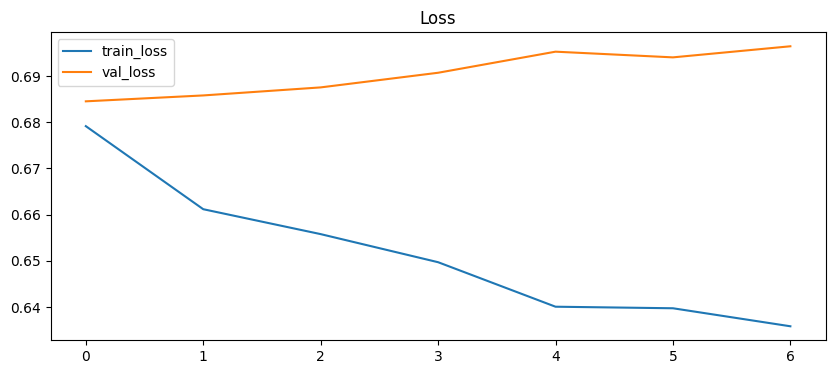

In [173]:
plt.figure(figsize=(10, 4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("Loss")
plt.legend()
plt.show()

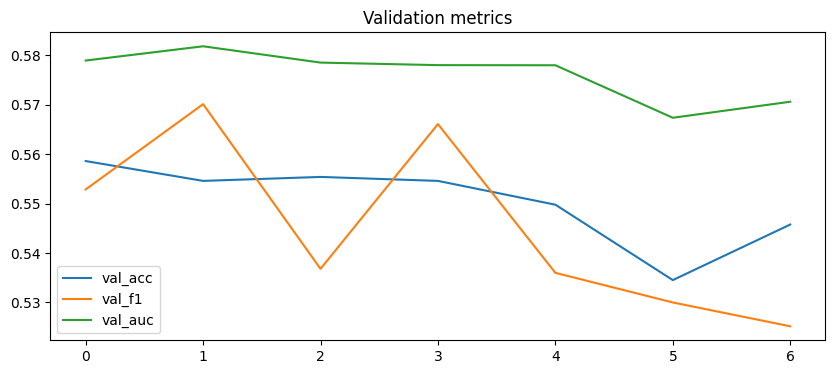

In [174]:
plt.figure(figsize=(10, 4))
plt.plot(history["val_acc"], label="val_acc")
plt.plot(history["val_f1"], label="val_f1")
plt.plot(history["val_auc"], label="val_auc")
plt.title("Validation metrics")
plt.legend()
plt.show()

## Оценка на test

In [175]:
test_loss, test_acc, test_f1, test_auc = evaluate_model(model, test_loader, device)

print("TEST RESULTS")
print(f"loss: {test_loss:.4f}")
print(f"accuracy: {test_acc:.4f}")
print(f"f1: {test_f1:.4f}")
print(f"auc: {test_auc:.4f}")

TEST RESULTS
loss: 0.6706
accuracy: 0.5725
f1: 0.5860
auc: 0.6182


## Детальный отчёт

In [176]:
def predict_with_model(model, loader, device):
    model.eval()

    all_probs = []
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            probs = torch.sigmoid(logits)
            preds = (probs >= 0.5).long()

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(y_batch.numpy())

    return np.array(all_targets), np.array(all_preds), np.array(all_probs)

In [177]:
y_true, y_pred, y_prob = predict_with_model(model, test_loader, device)

print(classification_report(y_true, y_pred, digits=4))

              precision    recall  f1-score   support

         0.0     0.5848    0.5338    0.5581       607
         1.0     0.5619    0.6121    0.5860       593

    accuracy                         0.5725      1200
   macro avg     0.5734    0.5730    0.5720      1200
weighted avg     0.5735    0.5725    0.5719      1200



### Вывод

**Что получилось сейчас:**

* Построена модель, которая предсказывает победу команды в матче NBA.
* Используются два типа признаков:

  * **игровая статистика прошлых матчей** (rolling-признаки),
  * **новостной фон команды** (количество новостей, тональность, ключевые слова).
* После устранения утечки данных модель показала примерно:

  * **accuracy ≈ 0.57**
  * **ROC-AUC ≈ 0.57**
* Это немного лучше случайного угадывания (0.5), значит:

  * в данных **есть небольшой прогностический сигнал**,
  * но текущие признаки пока не очень сильные.

### Как можно улучшить модель

**1. Улучшить агрегирование новостей**

Сейчас используются простые показатели за день. Лучше использовать окна:

* новости за **3 дня**
* новости за **7 дней**
* новости за **14 дней**

Это лучше отражает информационный фон вокруг команды.

**2. Добавить тематические признаки**

Разделить новости по типам:

* травмы игроков
* победы / поражения
* трейды
* дисквалификации
* возвращение игроков

Например:

* `injury_news_count_roll3`
* `trade_news_count_roll7`

Такие события часто напрямую влияют на результат матчей.

**3. Использовать текст заголовков**

Сейчас текст используется только через простые счётчики. Можно добавить:

* **TF-IDF признаки заголовков**
* уменьшение размерности (например, SVD)

Это позволит модели извлекать больше информации из самих текстов новостей.

**4. Учитывать разницу новостей между командами**

Не только новости команды, но и **разницу с соперником**:

* `sentiment_diff`
* `injury_news_diff`
* `news_count_diff`

Это помогает модели понять, у какой команды информационный фон лучше.

**5. Учитывать давность новостей**

Новость вчера важнее, чем неделю назад.
Можно использовать **взвешенные признаки**, где недавние новости имеют больший вес.
